# 01 — Exploratory Data Analysis

**H&M Personalized Fashion Recommendations**

BTEC L6 Unit 2 — Capstone Project · Lola Toirxonova (ID 220062)

---

## Goals of this notebook

Covers **P5, M3, M4** (data collection, interpretation, visualisation) and seeds **D3** (validity, cold-start segmentation).

1. Inspect the three CSVs: schema, dtypes, missingness, row counts.
2. Articles — category distribution, text-feature availability for TF-IDF.
3. Customers — demographic distribution.
4. Transactions — time range, daily volume, user/item activity distribution.
5. Compute **sparsity** of the user-item interaction matrix.
6. Long-tail analysis (Pareto curve of item popularity and user activity).
7. Cold-start segmentation prep (identify candidate cold users/items for evaluation).
8. Save EDA artefacts to `outputs/eda/`.

## Findings to write in your report

After running this notebook, document in `docs/eda_findings.md`:

- Sparsity percentage (expected: > 99.99%)
- Time range covered and any visible seasonality
- Long-tail shape — what % of items account for 80% of transactions?
- Demographic skew (age, gender if available)
- Cold-start exposure: in a held-out final week, how many users/items are unseen?

## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data as dataio

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

OUTPUT_DIR = REPO_ROOT / 'outputs' / 'eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f'Repo root: {REPO_ROOT}')
print(f'Output dir: {OUTPUT_DIR}')

Repo root: /Users/mirzohidabdurazzoqov/Documents/PDP/gradproject
Output dir: /Users/mirzohidabdurazzoqov/Documents/PDP/gradproject/outputs/eda


## 1. Articles (product catalogue)

In [2]:
articles = dataio.load_articles()
print(f'Articles shape: {articles.shape}')
articles.head()

Articles shape: (105542, 25)


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,0108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,0108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,0108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,0110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,0110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [3]:
print('--- dtypes ---')
print(articles.dtypes)
print('\n--- missingness (top 10) ---')
print(articles.isna().sum().sort_values(ascending=False).head(10))

--- dtypes ---
article_id                        str
product_code                    int64
prod_name                         str
product_type_no                 int64
product_type_name                 str
product_group_name                str
graphical_appearance_no         int64
graphical_appearance_name         str
colour_group_code               int64
colour_group_name                 str
perceived_colour_value_id       int64
perceived_colour_value_name       str
perceived_colour_master_id      int64
perceived_colour_master_name      str
department_no                   int64
department_name                   str
index_code                        str
index_name                        str
index_group_no                  int64
index_group_name                  str
section_no                      int64
section_name                      str
garment_group_no                int64
garment_group_name                str
detail_desc                       str
dtype: object

--- missingness (top

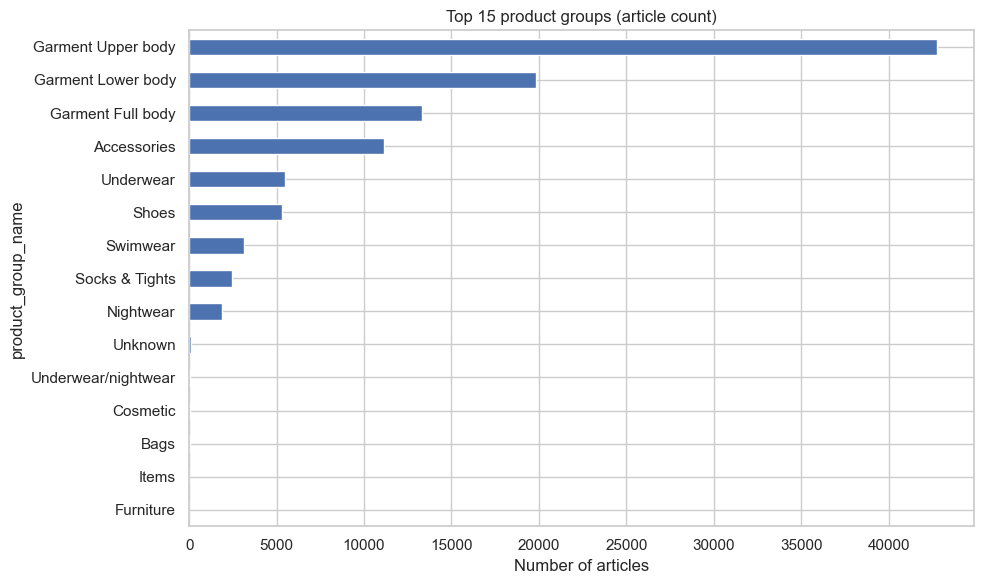

In [4]:
# Top product categories
fig, ax = plt.subplots(figsize=(10, 6))
articles['product_group_name'].value_counts().head(15).plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_title('Top 15 product groups (article count)')
ax.set_xlabel('Number of articles')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'articles_top_groups.png', dpi=150)
plt.show()

In [5]:
# Text features available for TF-IDF (content-based filtering)
text_cols = ['prod_name', 'detail_desc', 'product_type_name', 'product_group_name',
             'colour_group_name', 'department_name', 'index_group_name']
available = [c for c in text_cols if c in articles.columns]
print('Text columns available for TF-IDF:')
for c in available:
    null_pct = articles[c].isna().mean() * 100
    print(f'  {c:30s}  missing: {null_pct:.2f}%')

Text columns available for TF-IDF:
  prod_name                       missing: 0.00%
  detail_desc                     missing: 0.39%
  product_type_name               missing: 0.00%
  product_group_name              missing: 0.00%
  colour_group_name               missing: 0.00%
  department_name                 missing: 0.00%
  index_group_name                missing: 0.00%


## 2. Customers

In [6]:
customers = dataio.load_customers()
print(f'Customers shape: {customers.shape}')
customers.head()

Customers shape: (1371980, 7)


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [7]:
print('--- dtypes ---')
print(customers.dtypes)
print('\n--- missingness ---')
print(customers.isna().sum().sort_values(ascending=False))

--- dtypes ---
customer_id                   str
FN                        float64
Active                    float64
club_member_status            str
fashion_news_frequency        str
age                       float64
postal_code                   str
dtype: object

--- missingness ---
Active                    907576
FN                        895050
fashion_news_frequency     16011
age                        15861
club_member_status          6062
customer_id                    0
postal_code                    0
dtype: int64


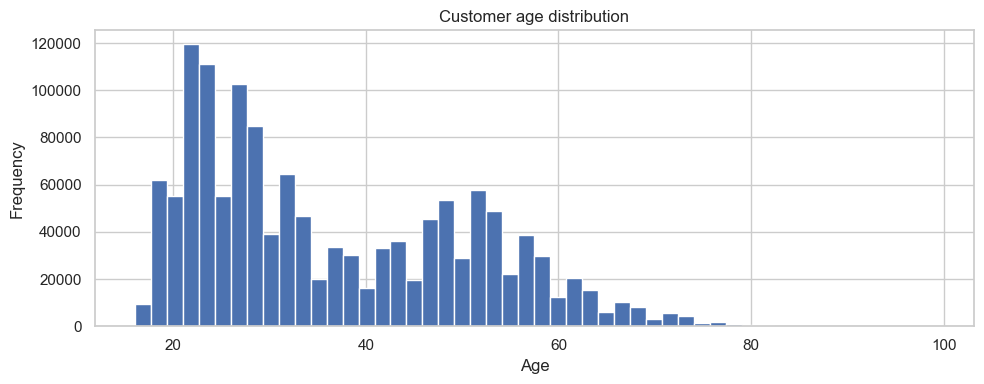

In [8]:
if 'age' in customers.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    customers['age'].dropna().plot(kind='hist', bins=50, ax=ax)
    ax.set_title('Customer age distribution')
    ax.set_xlabel('Age')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'customers_age_distribution.png', dpi=150)
    plt.show()

## 3. Transactions (implicit feedback)

**Memory warning:** the full file is ~31M rows. Start with a 1M-row sample. Switch to the full file only when running on Colab/Kaggle with more RAM.

In [9]:
transactions = dataio.load_transactions(sample_frac=0.03)  # ~1M random rows across all 31.8M
print(f'Transactions shape: {transactions.shape}')
print(f'Date range: {transactions["t_dat"].min()}  ->  {transactions["t_dat"].max()}')
transactions.head()

Transactions shape: (953626, 5)
Date range: 2018-09-20 00:00:00  ->  2020-09-22 00:00:00


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,0021da829b898f82269fc51feded4eac2129058ee95bd7...,0629760002,0.015237,1
1,2018-09-20,00609a1cc562140fa87a6de432bef9c9f0b936b259ad30...,0611415005,0.016932,2
2,2018-09-20,00b5b1446be091d4913765cf2cc01edc7e0d3820e1b8a4...,0627300001,0.024136,2
3,2018-09-20,00c59bdfaf753688c62cc13f67382dd54275f776a2f6a6...,0678073002,0.024424,2
4,2018-09-20,01271359dce99de537d6a3fca3c4dfd3732b455ec5085d...,0522561002,0.084729,2


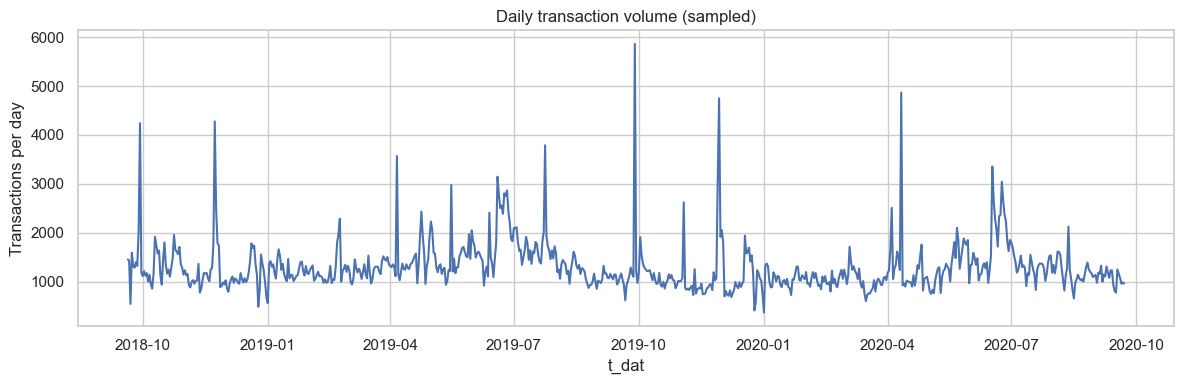

In [10]:
# Daily transaction volume
daily = transactions.groupby(transactions['t_dat'].dt.date).size()
fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax)
ax.set_title('Daily transaction volume (sampled)')
ax.set_ylabel('Transactions per day')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'transactions_daily_volume.png', dpi=150)
plt.show()

In [11]:
# User and item activity distributions
user_counts = transactions.groupby('customer_id').size()
item_counts = transactions.groupby('article_id').size()

print(f'Unique users in sample:  {user_counts.size:,}')
print(f'Unique items in sample:  {item_counts.size:,}')
print(f'\nUser activity — mean: {user_counts.mean():.2f}, median: {user_counts.median():.0f}, max: {user_counts.max()}')
print(f'Item popularity — mean: {item_counts.mean():.2f}, median: {item_counts.median():.0f}, max: {item_counts.max()}')

Unique users in sample:  473,944
Unique items in sample:  71,078

User activity — mean: 2.01, median: 1, max: 60
Item popularity — mean: 13.42, median: 5, max: 1508


## 4. Sparsity

Sparsity = 1 − (interactions / (users × items)). Above 99% is the norm for recommendation datasets and motivates matrix factorisation / NCF.

In [12]:
n_users = user_counts.size
n_items = item_counts.size
n_interactions = len(transactions)
density = n_interactions / (n_users * n_items)
print(f'Density:  {density * 100:.6f}%')
print(f'Sparsity: {(1 - density) * 100:.6f}%')

Density:  0.002831%
Sparsity: 99.997169%


## 5. Long-tail analysis

What % of items account for 80% of transactions? This shapes the popularity baseline and the cold-item story.

20,980 items (29.52%) account for 80% of transactions


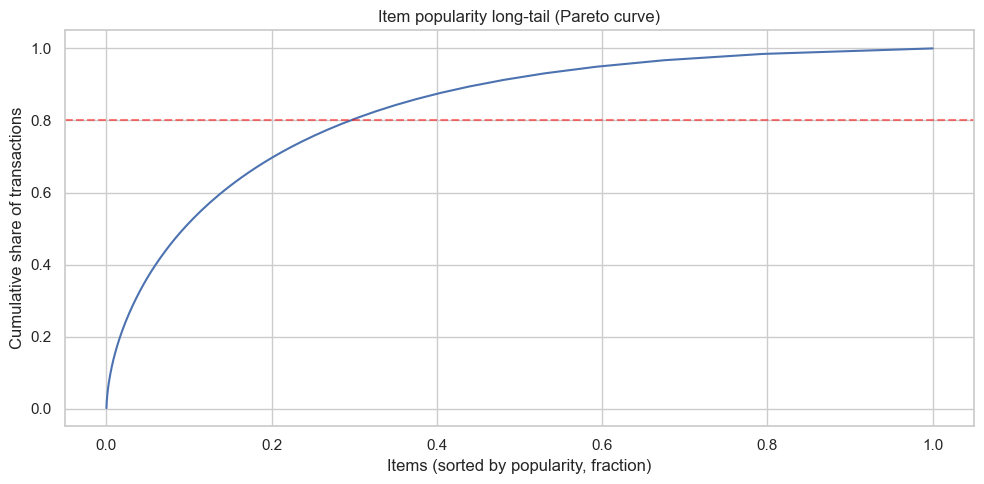

In [13]:
sorted_items = item_counts.sort_values(ascending=False).reset_index(drop=True)
cum_share = sorted_items.cumsum() / sorted_items.sum()
items_for_80pct = int((cum_share <= 0.80).sum() + 1)
print(f'{items_for_80pct:,} items ({items_for_80pct / n_items * 100:.2f}%) account for 80% of transactions')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(np.arange(len(cum_share)) / len(cum_share), cum_share.values)
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Items (sorted by popularity, fraction)')
ax.set_ylabel('Cumulative share of transactions')
ax.set_title('Item popularity long-tail (Pareto curve)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'transactions_long_tail.png', dpi=150)
plt.show()

## 6. Cold-start segmentation

Hold out the last 7 days as a pseudo-test set and measure how many users/items in that window are unseen in the training period. This is the **cold-start exposure** discussed in proposal §2 and is essential for D3 validity analysis.

In [14]:
train, test = dataio.time_based_split(transactions, cutoff_days=7)
cold_users = dataio.cold_user_ids(train, test)
cold_items = dataio.cold_item_ids(train, test)
test_users = test['customer_id'].nunique()
test_items = test['article_id'].nunique()

print(f'Train:  {len(train):>10,} rows, {train["customer_id"].nunique():>7,} users, {train["article_id"].nunique():>6,} items')
print(f'Test:   {len(test):>10,} rows, {test_users:>7,} users, {test_items:>6,} items')
print(f'\nCold users in test: {len(cold_users):>7,}  ({len(cold_users) / test_users * 100:.2f}% of test users)')
print(f'Cold items in test: {len(cold_items):>7,}  ({len(cold_items) / test_items * 100:.2f}% of test items)')

Train:     946,478 rows, 471,572 users, 70,575 items
Test:        7,148 rows,   6,548 users,  3,693 items

Cold users in test:   2,372  (36.22% of test users)
Cold items in test:     503  (13.62% of test items)


## 7. Save summary statistics

In [15]:
import json

summary = {
    'sample_size_transactions': int(len(transactions)),
    'n_articles': int(len(articles)),
    'n_customers_total': int(len(customers)),
    'n_users_in_sample': int(n_users),
    'n_items_in_sample': int(n_items),
    'sparsity_pct': float((1 - density) * 100),
    'items_for_80pct_transactions': int(items_for_80pct),
    'date_range_start': str(transactions['t_dat'].min().date()),
    'date_range_end': str(transactions['t_dat'].max().date()),
    'cold_user_pct_test': float(len(cold_users) / test_users * 100) if test_users else 0.0,
    'cold_item_pct_test': float(len(cold_items) / test_items * 100) if test_items else 0.0,
}

with open(OUTPUT_DIR / 'eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

summary

{'sample_size_transactions': 953626,
 'n_articles': 105542,
 'n_customers_total': 1371980,
 'n_users_in_sample': 473944,
 'n_items_in_sample': 71078,
 'sparsity_pct': 99.99716915653846,
 'items_for_80pct_transactions': 20980,
 'date_range_start': '2018-09-20',
 'date_range_end': '2020-09-22',
 'cold_user_pct_test': 36.224801466096515,
 'cold_item_pct_test': 13.620362848632547}

## Next steps

1. Write up findings in `docs/eda_findings.md` — copy the summary above + 3 figures + 1 paragraph each.
2. Update `logbook.md` with what you learned this week.
3. Move on to `02_content_based.ipynb` — TF-IDF on `detail_desc` + cosine similarity.